# Tutorial 14 — Синтетическая микроскопия и СЭМ-подобные изображения

Все примеры синтетические и используют явную ground truth.

In [1]:
LANGUAGE = "ru"
from pathlib import Path
import sys


def _find_repository_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Repository root not found. Open the notebook inside the repository.")


REPOSITORY_ROOT = _find_repository_root(Path.cwd().resolve())
SOURCE_DIRECTORY = REPOSITORY_ROOT / "src"
if str(SOURCE_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIRECTORY))

import biomechanics_tutorials
import matplotlib.pyplot as plt
import numpy as np
from biomechanics_tutorials.synthetic_fibrous_tissue import (
    generate_fiber_volume,
    rasterize_network,
    tissue_preset,
)
from biomechanics_tutorials.synthetic_microscopy import (
    ArtifactParameters,
    OpticalParameters,
    SEMParameters,
    apply_artifacts,
    export_multimodal_dataset,
    global_ssim,
    height_from_mask,
    psnr,
    simulate_brightfield,
    simulate_confocal_stack,
    simulate_fib_sem_stack,
    simulate_fluorescence,
    simulate_sem,
    simulate_shg,
)
from biomechanics_tutorials.plotting import apply_tutorial_style

apply_tutorial_style()


def tr(en, ru):
    return en if LANGUAGE == "en" else ru


print(Path(biomechanics_tutorials.__file__).resolve())

/mnt/data/Biomechanics-Research-Tutorials/src/biomechanics_tutorials/__init__.py


## 1. Общая синтетическая ground truth

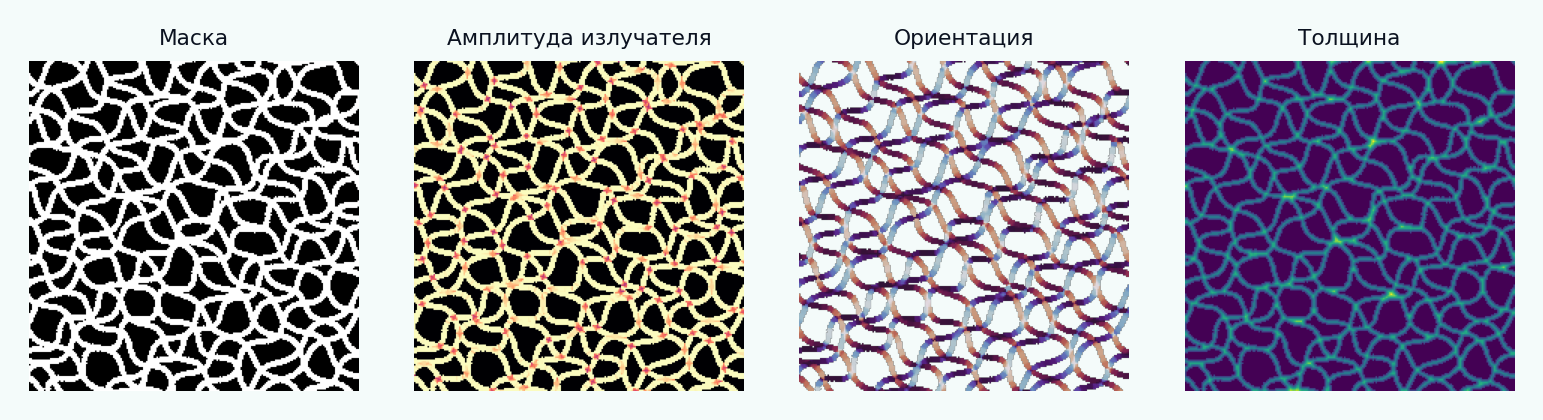

In [2]:
network = tissue_preset("skin", seed=14)
raster = rasterize_network(network, (220, 220), blur_sigma=0.3)
amplitude = raster.mask.astype(float) * (0.45 + 0.55 * raster.coherence)
orientation = np.where(raster.mask, raster.orientation, np.nan)
thickness = raster.thickness / max(np.max(raster.thickness), 1.0)
fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
for axis, array, title, cmap in zip(
    axes,
    [raster.mask, amplitude, np.rad2deg(orientation), thickness],
    [
        tr("Mask", "Маска"),
        tr("Emitter amplitude", "Амплитуда излучателя"),
        tr("Orientation", "Ориентация"),
        tr("Thickness", "Толщина"),
    ],
    ["gray", "magma", "twilight", "viridis"],
):
    axis.imshow(array, cmap=cmap)
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()
plt.show()

## 2. Широкопольная флуоресценция

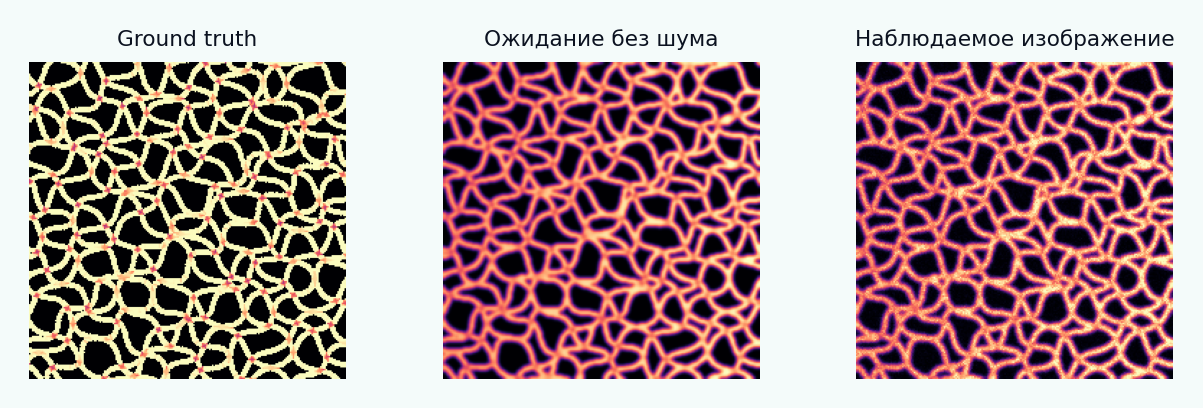

PSNR: 26.697
SSIM: 0.991


In [3]:
fluorescence = simulate_fluorescence(
    amplitude,
    OpticalParameters(sigma_xy=1.25, gain=300, background=0.03, read_noise=1.2),
    illumination_gradient=0.2,
    seed=4,
)
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.2))
for axis, array, title in zip(
    axes,
    [amplitude, fluorescence.expectation, fluorescence.image],
    [
        tr("Ground truth", "Ground truth"),
        tr("Noise-free expectation", "Ожидание без шума"),
        tr("Observed image", "Наблюдаемое изображение"),
    ],
):
    axis.imshow(array, cmap="magma")
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()
plt.show()
print("PSNR:", round(psnr(fluorescence.expectation, fluorescence.image), 3))
print("SSIM:", round(global_ssim(fluorescence.expectation, fluorescence.image), 4))

## 3. Светлопольное пропускание

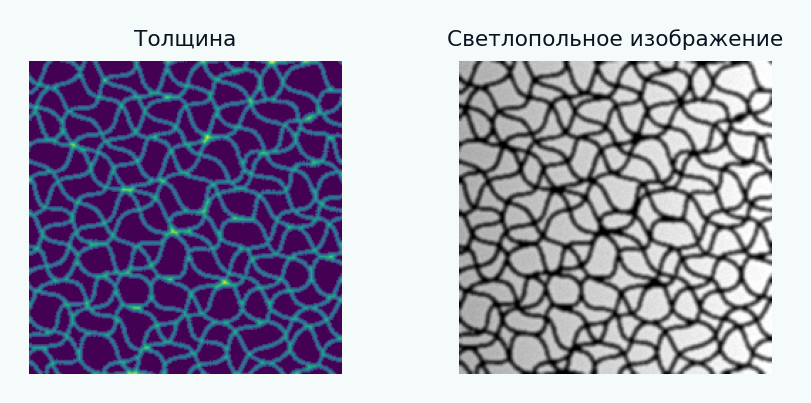

In [4]:
brightfield = simulate_brightfield(
    thickness,
    absorption=2.6,
    phase_edge_gain=0.18,
    illumination_gradient=0.25,
    seed=5,
)
fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.2))
axes[0].imshow(thickness, cmap="viridis")
axes[0].set_title(tr("Thickness", "Толщина"))
axes[1].imshow(brightfield.image, cmap="gray")
axes[1].set_title(tr("Bright-field-like", "Светлопольное изображение"))
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

## 4. Поляризационно-чувствительный SHG-подобный контраст

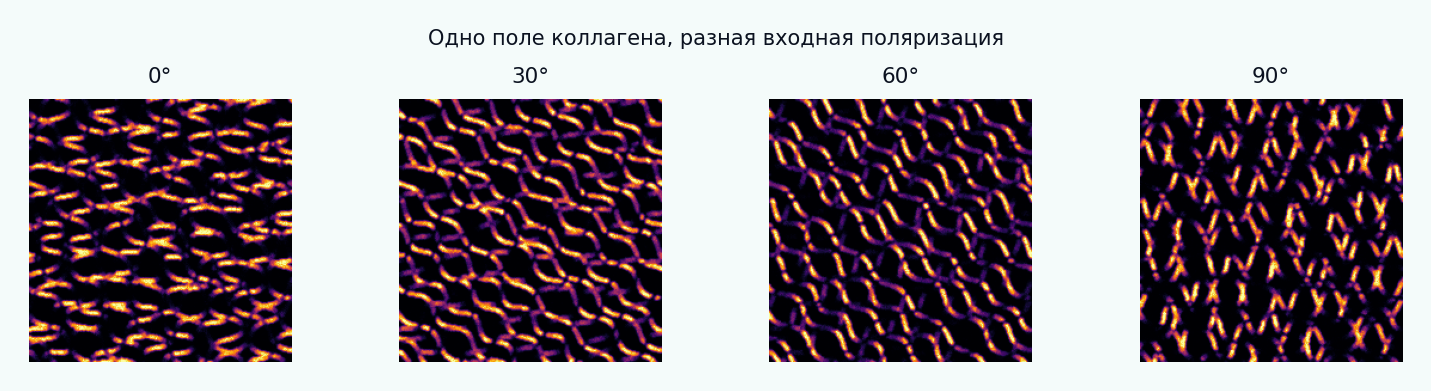

In [5]:
angles = np.deg2rad([0, 30, 60, 90])
fig, axes = plt.subplots(1, 4, figsize=(12.5, 3.0))
for axis, angle in zip(axes, angles):
    result = simulate_shg(amplitude, orientation, polarization_angle=float(angle), seed=6)
    axis.imshow(result.image, cmap="inferno")
    axis.set_title(f"{np.rad2deg(angle):.0f}°")
    axis.axis("off")
fig.suptitle(
    tr(
        "Same collagen field, different input polarization",
        "Одно поле коллагена, разная входная поляризация",
    )
)
plt.tight_layout()
plt.show()

## 5. СЭМ-подобная топография и направление детектора

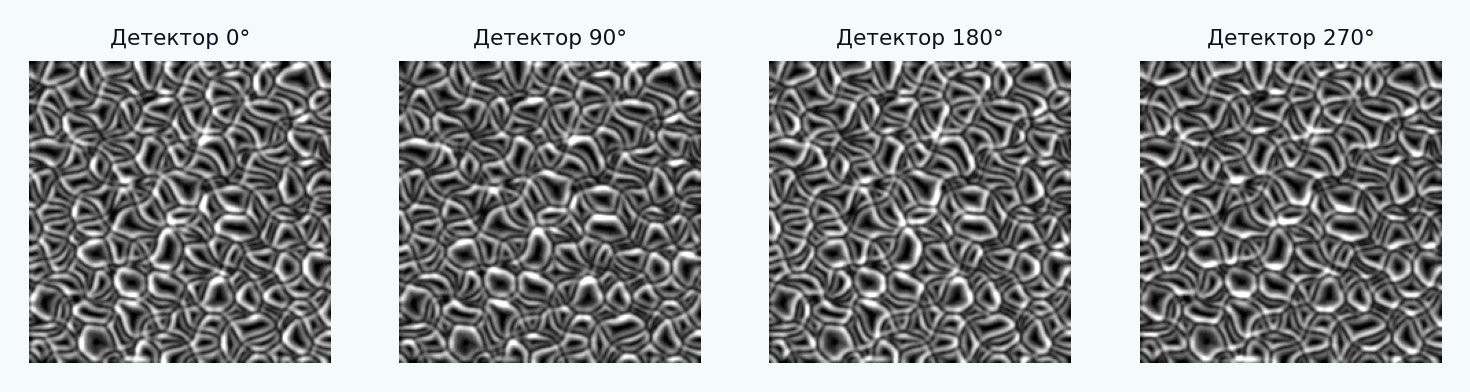

In [6]:
height = height_from_mask(raster.mask, sigma=1.8)
fig, axes = plt.subplots(1, 4, figsize=(12.5, 3.0))
for axis, azimuth in zip(axes, [0, 90, 180, 270]):
    result = simulate_sem(
        height,
        parameters=SEMParameters(detector_azimuth_deg=azimuth, noise_std=0.01),
        seed=7,
    )
    axis.imshow(result.image, cmap="gray")
    axis.set_title(tr(f"Detector {azimuth}°", f"Детектор {azimuth}°"))
    axis.axis("off")
plt.tight_layout()
plt.show()

## 6. Артефакты съёмки

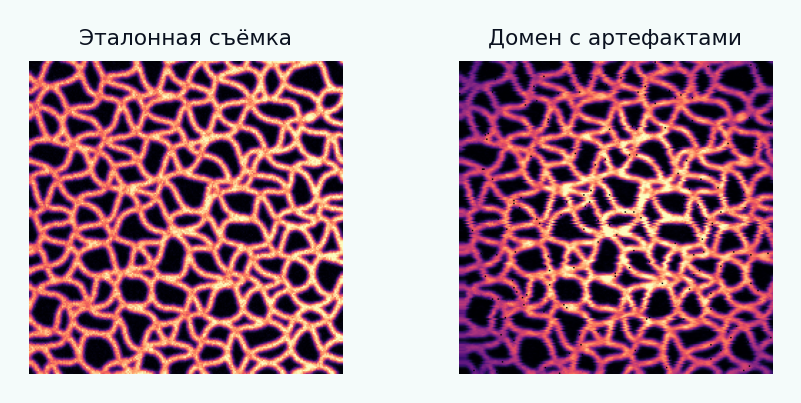

In [7]:
artifact_parameters = ArtifactParameters(
    vignette_strength=0.35,
    stripe_strength=0.1,
    drift_pixels=4.0,
    line_jitter=0.5,
    dead_pixel_fraction=0.005,
)
corrupted = apply_artifacts(fluorescence.image, artifact_parameters, seed=9)
fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.2))
axes[0].imshow(fluorescence.image, cmap="magma")
axes[0].set_title(tr("Reference acquisition", "Эталонная съёмка"))
axes[1].imshow(corrupted, cmap="magma")
axes[1].set_title(tr("Artifact domain", "Домен с артефактами"))
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

## 7. Конфокальный 3D-стек

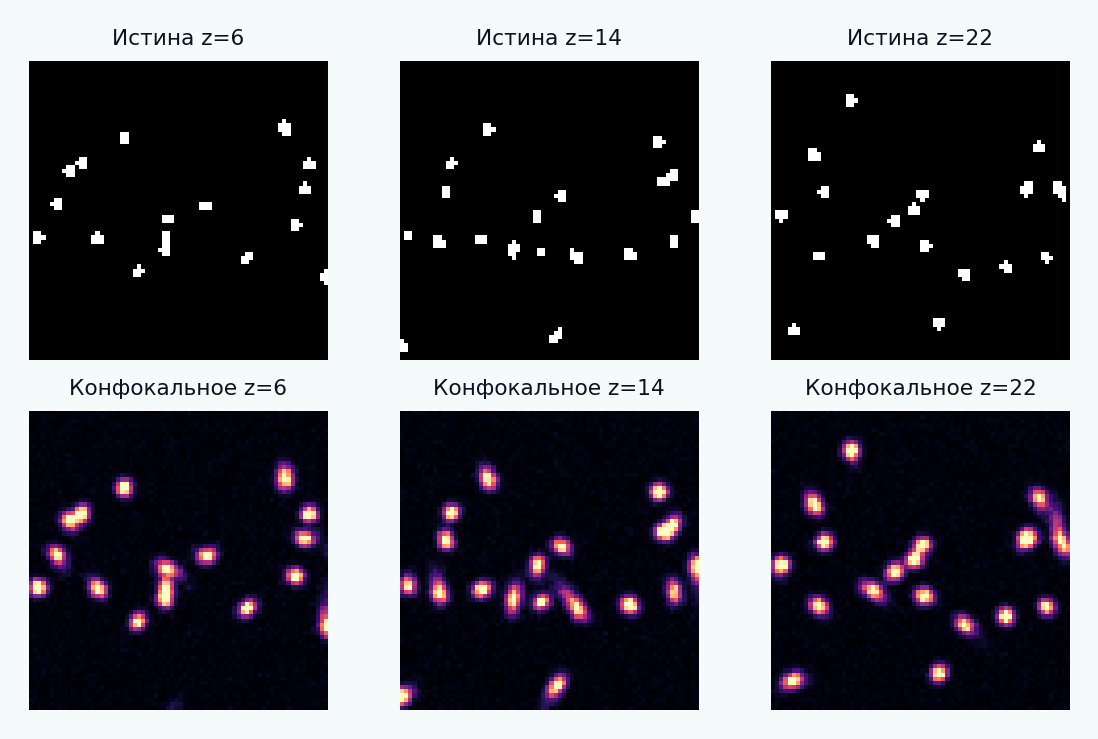

In [8]:
volume = generate_fiber_volume(
    (28, 72, 72), n_fibers=20, angular_noise=0.35, seed=15
).volume.astype(float)
confocal = simulate_confocal_stack(
    volume,
    OpticalParameters(sigma_xy=1.0, sigma_z=2.2, gain=450, read_noise=0.8),
    seed=10,
)
indices = [6, 14, 22]
fig, axes = plt.subplots(2, 3, figsize=(9.5, 6.0))
for column, index in enumerate(indices):
    axes[0, column].imshow(volume[index], cmap="gray")
    axes[0, column].set_title(tr(f"Ground truth z={index}", f"Истина z={index}"))
    axes[1, column].imshow(confocal.image[index], cmap="magma")
    axes[1, column].set_title(tr(f"Confocal-like z={index}", f"Конфокальное z={index}"))
for axis in axes.flat:
    axis.axis("off")
plt.tight_layout()
plt.show()

## 8. FIB-SEM-подобные серийные срезы

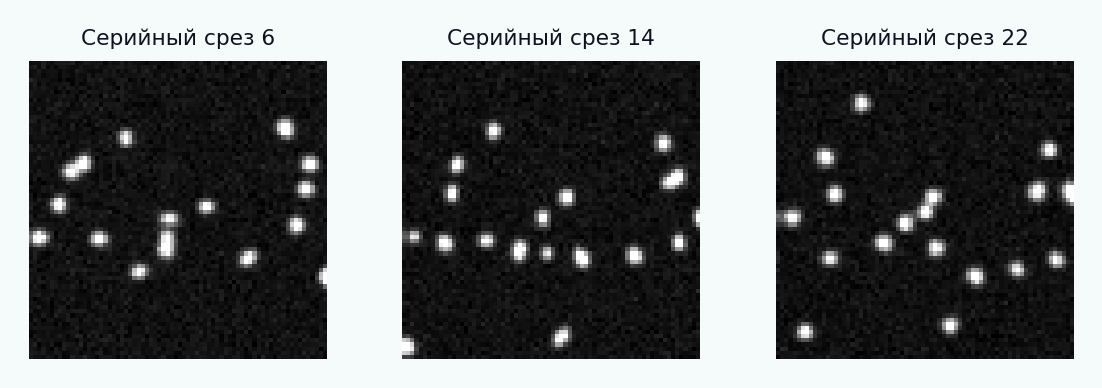

In [9]:
fib_sem = simulate_fib_sem_stack(
    volume,
    drift_per_slice=(0.03, 0.07),
    curtaining_strength=0.08,
    missing_slice_probability=0.03,
    seed=11,
)
fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.0))
for axis, index in zip(axes, indices):
    axis.imshow(fib_sem.image[index], cmap="gray")
    axis.set_title(tr(f"Serial section {index}", f"Серийный срез {index}"))
    axis.axis("off")
plt.tight_layout()
plt.show()

## 9. Экспорт синхронизированного мультимодального образца

In [10]:
output = (
    REPOSITORY_ROOT
    / "tutorials"
    / "14-synthetic-microscopy-sem-like-imaging"
    / "data"
    / "notebook_multimodal_sample.npz"
)
export_multimodal_dataset(
    output,
    ground_truth={"mask": raster.mask, "orientation": orientation, "thickness": thickness},
    modalities={
        "fluorescence": fluorescence.image,
        "brightfield": brightfield.image,
        "sem_like": simulate_sem(height, seed=12).image,
    },
    metadata={"seed": 14, "source": "Tutorial 14 notebook"},
)
print(output)
with np.load(output, allow_pickle=False) as archive:
    print(sorted(archive.files))

/mnt/data/Biomechanics-Research-Tutorials/tutorials/14-synthetic-microscopy-sem-like-imaging/data/notebook_multimodal_sample.npz
['gt_mask', 'gt_orientation', 'gt_thickness', 'image_brightfield', 'image_fluorescence', 'image_sem_like', 'metadata_json']


## 10. Интерпретация

In [11]:
print(
    tr(
        "A modality is an observation model, not the tissue itself. The same geometry can produce different intensities, artifacts, and apparent connectivity.",
        "Модальность — это модель наблюдения, а не сама ткань. Одна геометрия может создавать разные интенсивности, артефакты и видимую связность.",
    )
)

Модальность — это модель наблюдения, а не сама ткань. Одна геометрия может создавать разные интенсивности, артефакты и видимую связность.
